# Limits & Systems – LLM Performance Metrics

You have a working language model. It can answer questions, write code, summarize documents. Great.

Now someone asks: *Can we put this in front of real users?*

That question opens a can of worms. How long will people wait for a response? What happens when 50 users hit the model at the same time? How much GPU memory do you actually need?

This lab gives you the tools to work through those questions. You will write **5** small **metric helpers** (latency ratios, truncation flags, memory readouts, KV-cache size, batch throughput). After each helper, you run the notebook cells that load real models and apply your code to live measurements.

Everything you need to load models, format prompts, and draw plots is already in `utils.py`. You only write code inside the blocks marked with `### START CODE HERE ###` in the **graded** cells.

> **Autograder note:** The grader only executes cells tagged `graded`. Those cells must not load models or call `generate()` — they are pure functions so grading can run on a small CPU pod. The next setup cell after imports loads the weights and runs the experiments.


## Setup

Run the next **two** cells in order:

1. **Graded imports** — libraries only (no model weights).
2. **Models & helpers** — imports `utils`, defines which checkpoints to use, and loads `test_model` (this cell is *not* graded and is skipped by the autograder).

You don't need to change the setup cells unless you are pointing at different model IDs.


In [1]:
# Imports and setup (graded — no model weights)
import os, time, json, gc, math
from datetime import datetime
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU: AMD Instinct MI300X VF
GPU Memory: 205.8 GB


In [2]:
# Models and experiment helpers (loads weights — not executed by autograder)
from utils import (
    ModelWrapper,
    generate_prompt_of_length,
    measure_throughput,
    evaluate_model_on_task,
    get_gpu_memory_info as _utils_get_gpu_memory_info,
    TEST_TASKS,
    TOKEN_LIMIT_TASKS,
    run_model_comparison,
    run_token_limit_experiment,
    run_memory_tracking,
    run_batch_experiment,
    run_streaming_latency_timings,
    measure_memory_with_sequence_length,
    run_batched_inference_raw,
    plot_model_comparison,
    plot_token_limit_impact,
    plot_kv_cache_growth,
    plot_batching_results,
    plot_model_memory,
)

MODEL_CONFIGS = {
    "qwen-0.5b": {"name": "Qwen/Qwen2.5-0.5B-Instruct", "size": "0.5B", "category": "tiny"},
    "qwen-1.5b": {"name": "Qwen/Qwen2.5-1.5B-Instruct", "size": "1.5B", "category": "small"},
    "qwen-3b":   {"name": "Qwen/Qwen2.5-3B-Instruct",   "size": "3B",   "category": "medium"},
    "qwen-7b":   {"name": "Qwen/Qwen2.5-7B-Instruct",   "size": "7B",   "category": "large"},
}

MODELS_TO_USE = ["qwen-0.5b", "qwen-1.5b", "qwen-3b", "qwen-7b"]
models = {key: ModelWrapper(key, MODEL_CONFIGS[key]) for key in MODELS_TO_USE}

test_model = models[MODELS_TO_USE[0]]
test_model.load()
print(f"\nReady with {test_model.model_key}")


Loading Qwen/Qwen2.5-0.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-0.5B-Instruct

Ready with qwen-0.5b


### Throughput

Throughput = output tokens / generation time. This tells you how many concurrent users one GPU can support.
The `measure_throughput` helper in `utils.py` wraps `model.generate()` and returns tokens-per-second.

> **Why does throughput matter?**
> A single GPU generating 50 tokens/second can serve about 3 concurrent chat users comfortably (each user needs ~15 tok/s for a smooth streaming experience). At 200 tok/s you can serve ~12 users from one GPU.
> Throughput scales roughly linearly with batch size until you hit a memory wall — which is why batching (Exercise 5) and memory management (Exercises 3–4) are so tightly connected.
>
> For a deeper dive, see [Anyscale's LLM throughput guide](https://www.anyscale.com/blog/continuous-batching-llm-inference).


In [3]:
# Measure throughput across all models
print("Throughput comparison:\n")
for model_key in MODELS_TO_USE:
    mw = models[model_key]
    mw.load()
    result = measure_throughput(mw, "Write a detailed explanation of how neural networks learn.")
    print(f"  {model_key:>10s} ({mw.config['size']:>4s}): "
          f"{result['throughput']:6.1f} tok/s | "
          f"{result['output_tokens']} tokens in {result['total_time_s']:.2f}s")
    mw.unload()
test_model.load()

Throughput comparison:

   qwen-0.5b (0.5B):   10.6 tok/s | 100 tokens in 9.39s
✓ Unloaded Qwen/Qwen2.5-0.5B-Instruct
Loading Qwen/Qwen2.5-1.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-1.5B-Instruct
   qwen-1.5b (1.5B):   71.0 tok/s | 100 tokens in 1.41s
✓ Unloaded Qwen/Qwen2.5-1.5B-Instruct
Loading Qwen/Qwen2.5-3B-Instruct...
✓ Loaded Qwen/Qwen2.5-3B-Instruct
     qwen-3b (  3B):   55.8 tok/s | 100 tokens in 1.79s
✓ Unloaded Qwen/Qwen2.5-3B-Instruct
Loading Qwen/Qwen2.5-7B-Instruct...
✓ Loaded Qwen/Qwen2.5-7B-Instruct
     qwen-7b (  7B):   71.0 tok/s | 100 tokens in 1.41s
✓ Unloaded Qwen/Qwen2.5-7B-Instruct
Loading Qwen/Qwen2.5-0.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-0.5B-Instruct


---

## Streaming vs Non-Streaming

When you use ChatGPT, words appear on screen as the model produces them. That's streaming. The total wait for the full answer is often similar to non-streaming generation, but the experience feels better because you start reading immediately instead of staring at a loading spinner.

### Exercise 1 – Compare Streaming and Non-Streaming

The **graded** function below does **not** run the model. It only turns **two wall-clock times** (non-streaming vs streaming, in milliseconds) plus the token count into a summary dict, including:

`total_time_ratio = streaming_total_ms / non_streaming_total_ms`

In the next (non-graded) cell, `utils.run_streaming_latency_timings(...)` runs the real `generate()` and streaming loop on GPU, then passes the measured milliseconds into your function.

**Complete the single line** between `### START CODE HERE ###` and `### END CODE HERE ###`:

```python
    total_time_ratio = streaming_total_ms / non_streaming_total_ms if non_streaming_total_ms > 0 else 0.0
```

> **How KV cache makes streaming efficient:** Without the cache, each new token would require re-processing the entire sequence. With it, the model stores intermediate attention states (`past_key_values`) and only processes the latest token.


In [4]:
# GRADED CELL: exercise 1
def compare_streaming_latency(
    non_streaming_total_ms: float,
    streaming_total_ms: float,
    output_tokens: int,
    model_key: str,
) -> Dict:
    """
    Package wall-clock timings from a streaming vs non-streaming run into one dict.
    Use utils.run_streaming_latency_timings(...) in the lab to obtain the times.
    """
    ### START CODE HERE ###
    total_time_ratio = streaming_total_ms / non_streaming_total_ms if non_streaming_total_ms > 0 else 0.0
    ### END CODE HERE ###
    return {
        "model": model_key,
        "non_streaming_total_ms": non_streaming_total_ms,
        "streaming_total_ms": streaming_total_ms,
        "total_time_ratio": total_time_ratio,
        "output_tokens": output_tokens,
    }


In [5]:
# Streaming vs non-streaming — all models
print("Streaming vs non-streaming comparison:\n")
for model_key in MODELS_TO_USE:
    mw = models[model_key]
    mw.load()
    timings = run_streaming_latency_timings(mw, "Explain how a neural network learns in detail.")
    result = compare_streaming_latency(
        timings["non_streaming_total_ms"],
        timings["streaming_total_ms"],
        timings["output_tokens"],
        mw.model_key,
    )
    print(f"  {model_key:>10s} ({mw.config['size']:>4s}): "
          f"Non-stream={result['non_streaming_total_ms']:7.0f}ms | "
          f"Stream={result['streaming_total_ms']:7.0f}ms | "
          f"Ratio={result['total_time_ratio']:.2f}")
    mw.unload()
test_model.load()


Streaming vs non-streaming comparison:

   qwen-0.5b (0.5B): Non-stream=   1285ms | Stream=   1177ms | Ratio=0.92
✓ Unloaded Qwen/Qwen2.5-0.5B-Instruct
Loading Qwen/Qwen2.5-1.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-1.5B-Instruct
   qwen-1.5b (1.5B): Non-stream=   1477ms | Stream=   1417ms | Ratio=0.96
✓ Unloaded Qwen/Qwen2.5-1.5B-Instruct
Loading Qwen/Qwen2.5-3B-Instruct...
✓ Loaded Qwen/Qwen2.5-3B-Instruct
     qwen-3b (  3B): Non-stream=   1869ms | Stream=   1861ms | Ratio=1.00
✓ Unloaded Qwen/Qwen2.5-3B-Instruct
Loading Qwen/Qwen2.5-7B-Instruct...
✓ Loaded Qwen/Qwen2.5-7B-Instruct
     qwen-7b (  7B): Non-stream=   1450ms | Stream=   1424ms | Ratio=0.98
✓ Unloaded Qwen/Qwen2.5-7B-Instruct
Loading Qwen/Qwen2.5-0.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-0.5B-Instruct


---

# Section 2 – Picking the Right Model

A tiny 0.5B model and a bigger 3B model can both answer "What is the capital of France?" correctly. But throw a multi-step word problem at them and the gap shows up fast.

Bigger models are slower and more expensive. Smaller models are cheap and quick but stumble on harder questions. The only way to decide which one fits your use case is to run them side by side on the actual tasks you care about.

## Comparing Models

Smaller models are faster and cheaper. Larger models are more accurate.
The `evaluate_model_on_task` helper in `utils.py` runs a prompt, checks if the expected answer appears in the output, and records latency.

Below we compare all loaded models across the test tasks defined in `utils.TEST_TASKS`.


Testing qwen-0.5b (0.5B):
  ✓ Simple Q&A
  ✓ Basic Math
  ✓ Science Fact
  ✓ Logical Reasoning
  ✓ Code Understanding
  ✗ Multi-Step Reasoning
Loading Qwen/Qwen2.5-1.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-1.5B-Instruct

Testing qwen-1.5b (1.5B):
  ✓ Simple Q&A
  ✓ Basic Math
  ✓ Science Fact
  ✓ Logical Reasoning
  ✓ Code Understanding
  ✗ Multi-Step Reasoning
Loading Qwen/Qwen2.5-3B-Instruct...
✓ Loaded Qwen/Qwen2.5-3B-Instruct

Testing qwen-3b (3B):
  ✓ Simple Q&A
  ✓ Basic Math
  ✓ Science Fact
  ✓ Logical Reasoning
  ✓ Code Understanding
  ✓ Multi-Step Reasoning
Loading Qwen/Qwen2.5-7B-Instruct...
✓ Loaded Qwen/Qwen2.5-7B-Instruct

Testing qwen-7b (7B):
  ✓ Simple Q&A
  ✓ Basic Math
  ✓ Science Fact
  ✓ Logical Reasoning
  ✓ Code Understanding
  ✓ Multi-Step Reasoning


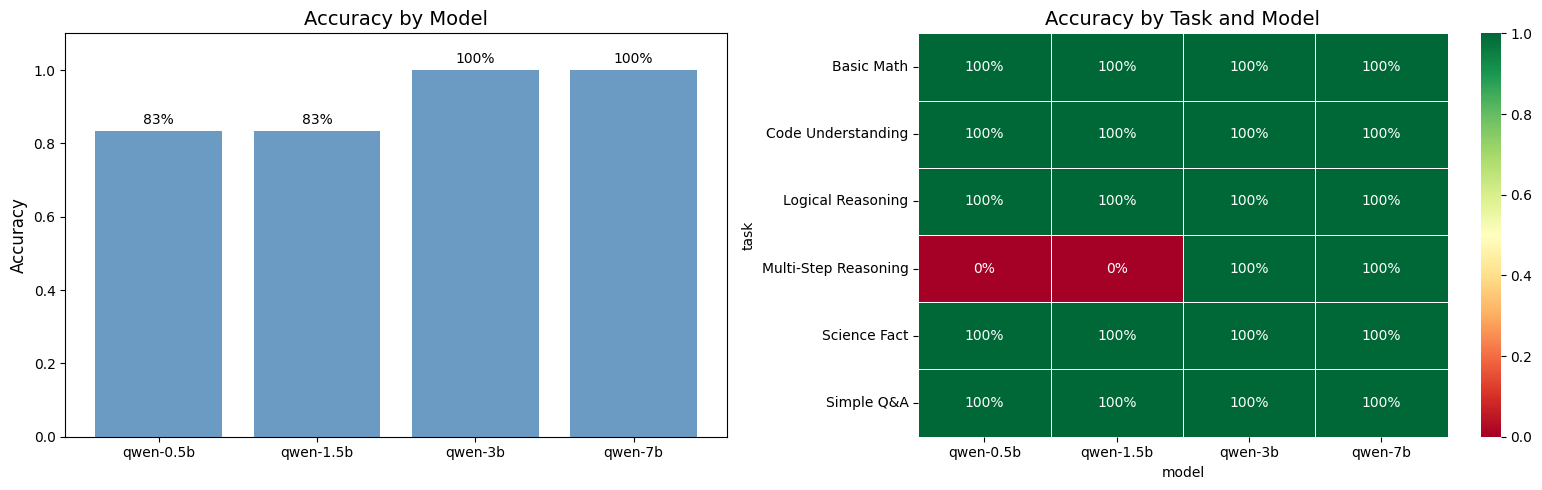

In [8]:
comparison_df = run_model_comparison(models, MODELS_TO_USE)
plot_model_comparison(comparison_df, MODELS_TO_USE)

### Exercise 2 – What Happens When You Limit Output Length

In production you usually cap `max_tokens` to control costs and stop the model from rambling. But if the limit is too tight, the response gets chopped mid-sentence.

The **graded** function below does **not** call the model. It takes a **`generation_result`** dict (the kind returned by `ModelWrapper.generate()` in `utils.py`) and decides:

1. **Truncated?** – `True` when `generation_result['output_tokens'] >= max_tokens`.
2. **Still correct?** – When `task` includes an `'expected'` string, check whether that text appears in `generation_result['response']` (case-insensitive, using `.lower()` and `in`). If there is no `'expected'` key, leave `correct` as `None`.

The next cells call `model_wrapper.generate(...)` first, then pass the result into your function.

#### What `generation_result` contains

Same keys as `ModelWrapper.generate`: at least `output_tokens`, `response`, and `total_time_ms` (the return dict below forwards latency and token counts).

**Complete the code** between `### START CODE HERE ###` and `### END CODE HERE ###` to set `truncated` and `correct`.


In [11]:
# GRADED CELL: exercise 2
def evaluate_with_token_limit(generation_result: Dict, task: Dict, max_tokens: int) -> Dict:
    """
    Truncation + correctness from an existing generation dict (no model call here).
    """
    ### START CODE HERE ###
    truncated = generation_result['output_tokens'] >= max_tokens
    correct = None
    if task.get("expected"):
        correct = task["expected"].lower() in generation_result['response'].lower()
    ### END CODE HERE ###
    return {
        "task": task["name"],
        "max_tokens": max_tokens,
        "actual_tokens": generation_result["output_tokens"],
        "latency_ms": generation_result["total_time_ms"],
        "truncated": truncated,
        "correct": correct,
        "reasoning_needed": task["reasoning_needed"],
        "response": generation_result["response"],
    }



  qwen-0.5b (0.5B)
  [  ok ] ✓      One-word answer @   5 tokens |   3 generated | Tokyo
  [  ok ] ✓      One-word answer @  10 tokens |   3 generated | Tokyo
  [  ok ] ✓      One-word answer @  20 tokens |   3 generated | Tokyo
  [  ok ] ✓      One-word answer @  50 tokens |   3 generated | Tokyo
  [  ok ] ✓      One-word answer @ 100 tokens |   3 generated | Tokyo
  [  ok ] ✓      One-word answer @ 200 tokens |   3 generated | Tokyo
  [  ok ] ✓           Short math @   5 tokens |   4 generated | 180
  [  ok ] ✓           Short math @  10 tokens |   4 generated | 180
  [  ok ] ✓           Short math @  20 tokens |   4 generated | 180
  [  ok ] ✓           Short math @  50 tokens |   4 generated | 180
  [  ok ] ✓           Short math @ 100 tokens |   4 generated | 180
  [  ok ] ✓           Short math @ 200 tokens |   4 generated | 180
  [TRUNC] ✗    Brief explanation @   5 tokens |   5 generated | Ice floats on water because
  [TRUNC] ✗    Brief explanation @  10 tokens |  10 generate

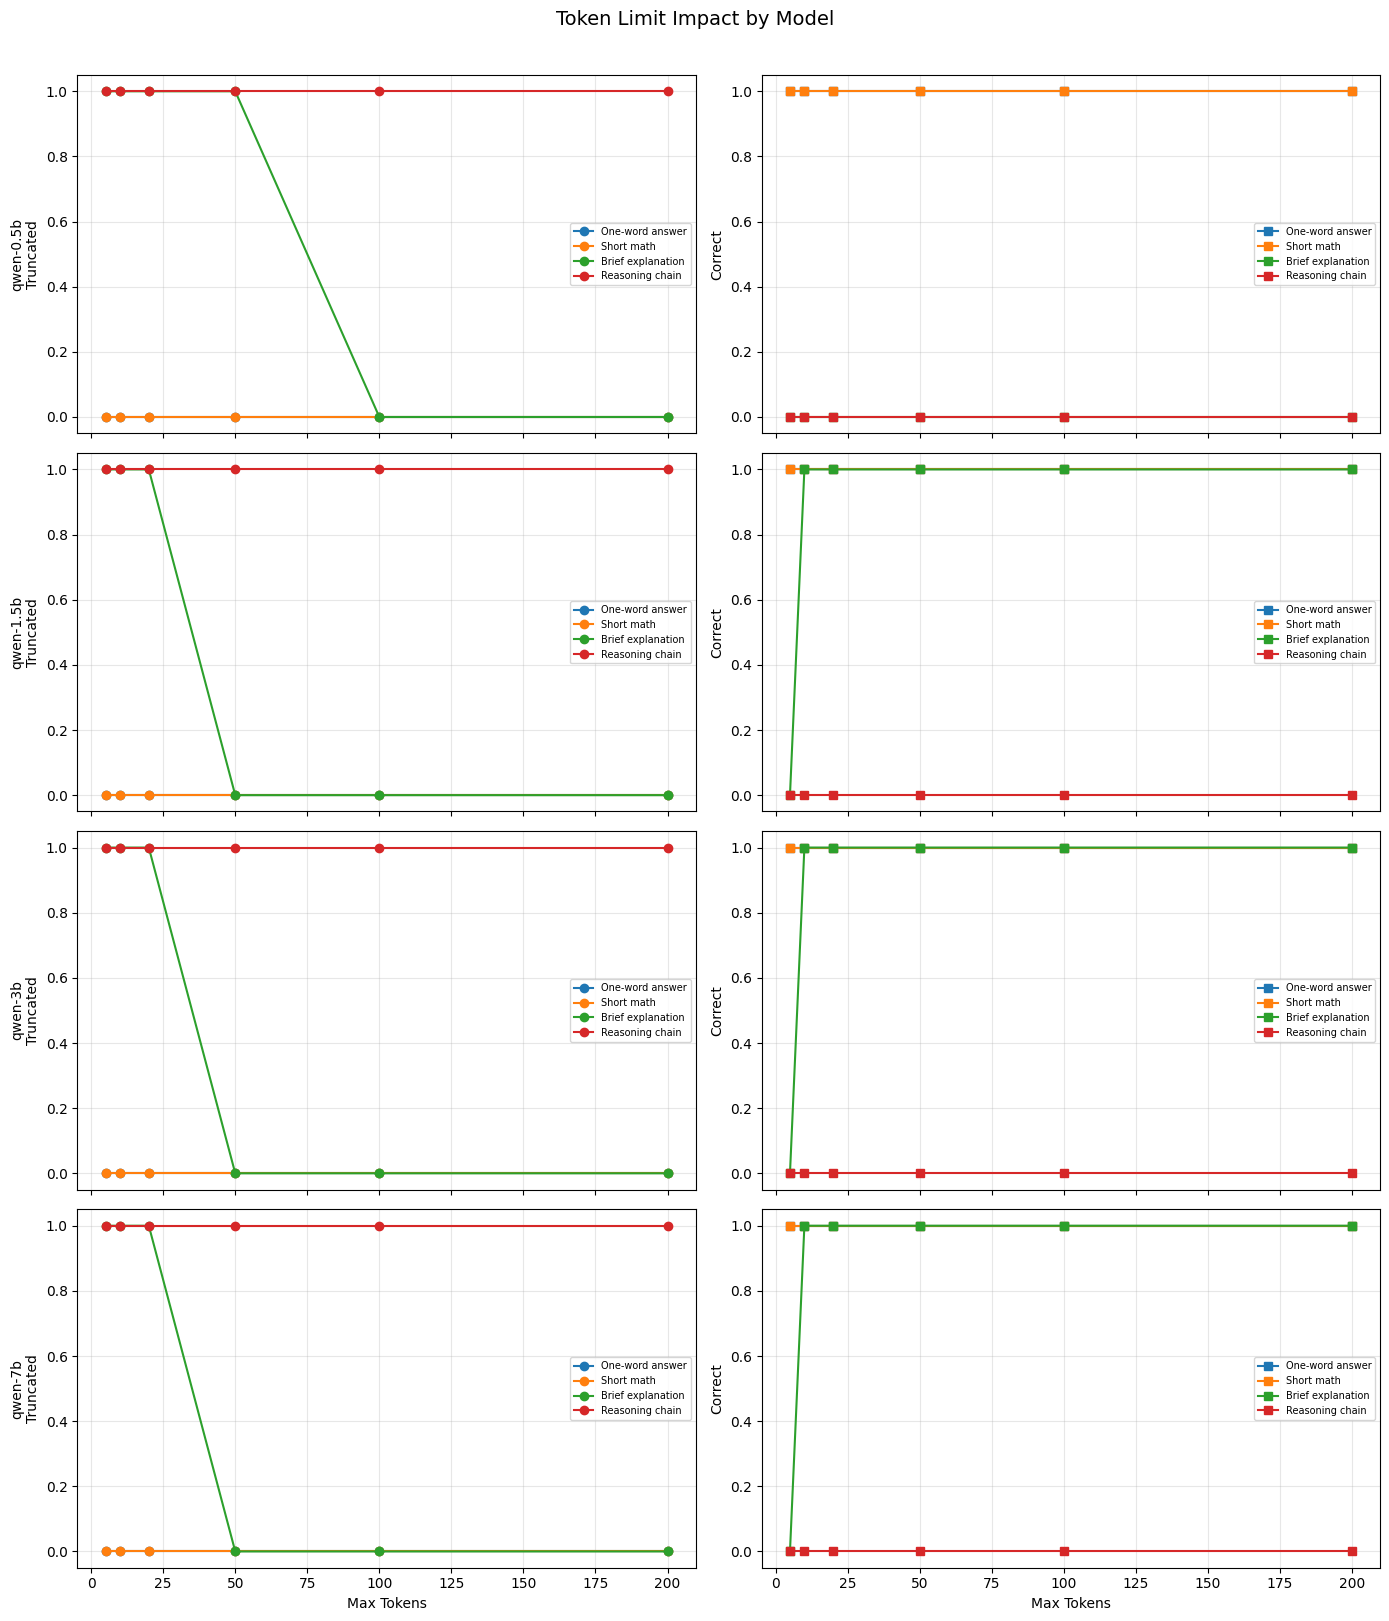

In [12]:
# Token limit impact — all models
all_token = []
for model_key in MODELS_TO_USE:
    mw = models[model_key]
    mw.load()
    print(f"\n{'='*60}")
    print(f"  {model_key} ({mw.config['size']})")
    print(f"{'='*60}")
    df = run_token_limit_experiment(mw, evaluate_with_token_limit)
    df["model"] = model_key
    all_token.append(df)
    mw.unload()
test_model.load()

token_df = pd.concat(all_token, ignore_index=True)
plot_token_limit_impact(token_df)

---

# Section 3 – GPU Memory

Everything so far has been about time. Now let's talk about space.

A model needs GPU memory for two things:

1. **Weights** – The learned parameters. This is a fixed cost, always present. A 1.5B-parameter model in FP16 takes about 3 GB.
2. **KV cache** – The attention states the model builds up as it reads and writes tokens. This grows with conversation length and the number of concurrent users.

If total usage exceeds GPU memory, the process crashes. So understanding where memory goes is the first step toward fitting bigger models or serving more users on the same hardware.

> **Quick reference – memory cost by precision:**
>
> | Precision | Bytes per param | 1B model | 7B model | 70B model |
> |-----------|----------------|----------|----------|-----------|
> | FP32      | 4              | 4 GB     | 28 GB    | 280 GB    |
> | FP16/BF16 | 2              | 2 GB     | 14 GB    | 140 GB    |
> | INT8      | 1              | 1 GB     | 7 GB     | 70 GB     |
> | INT4      | 0.5            | 0.5 GB   | 3.5 GB   | 35 GB     |
>
> These are just the weights. KV cache and activations add on top.


### Exercise 3 – Read GPU Memory

Implement `get_gpu_memory_info` so it reads current GPU memory stats and returns them as a dict (values in MB). The helper `print_gpu_memory` below already calls `get_gpu_memory_info` and prints the numbers in a readable format — you only need to fill in **one code region** inside `get_gpu_memory_info`.

PyTorch gives you everything you need (all values are in bytes — divide by `1024**2` for MB):
- `torch.cuda.memory_allocated()` – memory used by tensors right now
- `torch.cuda.memory_reserved()` – memory the allocator has set aside (includes free pools)
- `torch.cuda.max_memory_allocated()` – the peak since the last reset
- `torch.cuda.get_device_properties(0).total_memory` – total GPU capacity



In [13]:
# GRADED CELL: exercise 3
# GPU Memory Monitoring Utilities
def get_gpu_memory_info():
    """Get current GPU memory usage in MB for precision with small allocations."""
    if not torch.cuda.is_available():
        return {"allocated_mb": 0, "reserved_mb": 0, "peak_mb": 0, "total_mb": 0, "free_mb": 0}

    ### START CODE HERE ###
    allocated = torch.cuda.memory_allocated()
    reserved = torch.cuda.memory_reserved()
    peak = torch.cuda.max_memory_allocated()
    total = torch.cuda.get_device_properties(0).total_memory
    ### END CODE HERE ###

    return {
        "allocated_mb": round(allocated, 1),
        "reserved_mb": round(reserved, 1),
        "peak_mb": round(peak, 1),
        "total_mb": round(total, 1),
        "free_mb": round(total - reserved, 1)
    }

def print_gpu_memory(label=""):
    """Print current GPU memory status."""
    info = get_gpu_memory_info()
    print(f"{label}")
    print(f"  Allocated: {info['allocated_mb']:,.1f} MB  ({info['allocated_mb']/1024:.2f} GB)")
    print(f"  Reserved:  {info['reserved_mb']:,.1f} MB  ({info['reserved_mb']/1024:.2f} GB)")
    print(f"  Peak:      {info['peak_mb']:,.1f} MB  ({info['peak_mb']/1024:.2f} GB)")
    print(f"  Free:      {info['free_mb']:,.1f} MB  ({info['free_mb']/1024:.2f} GB)")
    return info

# Check current memory state


In [14]:
print_gpu_memory("Current GPU Memory:")

Current GPU Memory:
  Allocated: 1,067,789,312.0 MB  (1042763.00 GB)
  Reserved:  1,098,907,648.0 MB  (1073152.00 GB)
  Peak:      27,740,418,048.0 MB  (27090252.00 GB)
  Free:      204,723,978,240.0 MB  (199925760.00 GB)


{'allocated_mb': 1067789312,
 'reserved_mb': 1098907648,
 'peak_mb': 27740418048,
 'total_mb': 205822885888,
 'free_mb': 204723978240}

#### How much memory does each model use?

Let's load each model one at a time and measure the memory jump. The numbers should line up roughly with `parameters × 2 bytes` (FP16).

In [15]:
memory_df = run_memory_tracking(models, MODELS_TO_USE, get_gpu_memory_info)

Baseline memory: 1,067,789,312.0 MB

✓ Unloaded Qwen/Qwen2.5-0.5B-Instruct
Loading Qwen/Qwen2.5-0.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-0.5B-Instruct
qwen-0.5b (0.5B):
  Model memory: 988,097,536.0 MB  (964939.00 GB)
  Total allocated: 1,067,789,312.0 MB  (1042763.00 GB)

✓ Unloaded Qwen/Qwen2.5-0.5B-Instruct
Loading Qwen/Qwen2.5-1.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-1.5B-Instruct
qwen-1.5b (1.5B):
  Model memory: 3,087,429,632.0 MB  (3015068.00 GB)
  Total allocated: 3,167,121,408.0 MB  (3092892.00 GB)

✓ Unloaded Qwen/Qwen2.5-1.5B-Instruct
Loading Qwen/Qwen2.5-3B-Instruct...
✓ Loaded Qwen/Qwen2.5-3B-Instruct
qwen-3b (3B):
  Model memory: 6,171,878,400.0 MB  (6027225.00 GB)
  Total allocated: 6,251,570,176.0 MB  (6105049.00 GB)

✓ Unloaded Qwen/Qwen2.5-3B-Instruct
Loading Qwen/Qwen2.5-7B-Instruct...
✓ Loaded Qwen/Qwen2.5-7B-Instruct
qwen-7b (7B):
  Model memory: 15,231,234,048.0 MB  (14874252.00 GB)
  Total allocated: 15,310,925,824.0 MB  (14952076.00 GB)

✓ Unloaded Qwen/Qwen2.5-7B-I

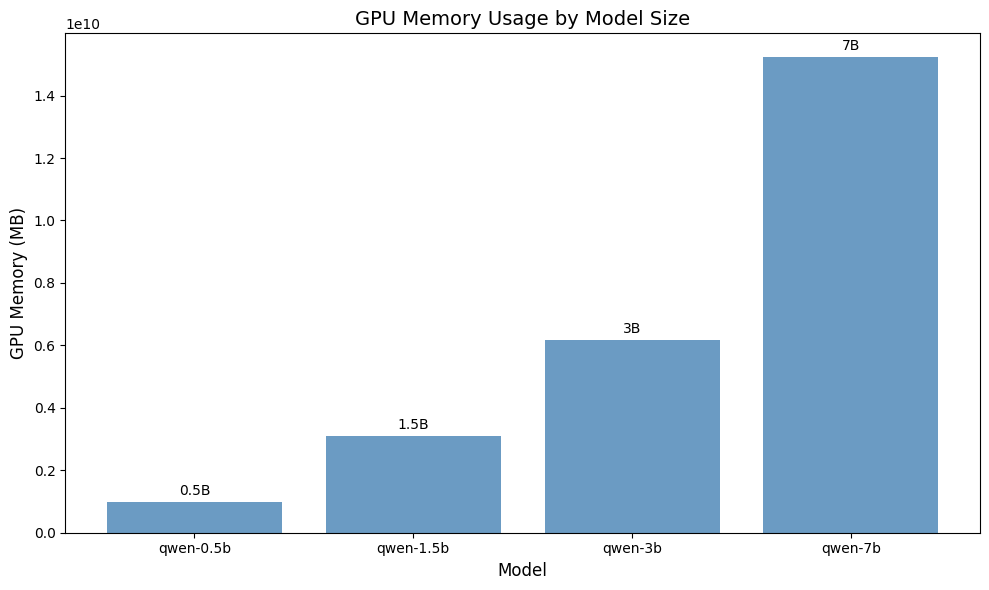

In [16]:
plot_model_memory(memory_df)

### Exercise 4 – Theoretical KV Cache Size

The KV cache stores attention keys and values for every token the model has seen so far. Its size grows roughly linearly with sequence length:

```
KV cache (bytes) ≈ 2 × layers × kv_heads × head_dim × seq_length × bytes_per_element
```

The factor **2** is for **keys and values** together.

The **graded** function below is **pure math** (no `model.forward`). When you run the KV experiment cell on a GPU, `utils.measure_memory_with_sequence_length(...)` calls this helper for each sequence length so you can compare theory to measured memory.

> **Note:** `get_gpu_memory_info` in Exercise 3 is separate; the measurement loop lives in `utils.py`.

**Complete the `return` expression** between `### START CODE HERE ###` and `### END CODE HERE ###` — convert the byte count above into **megabytes** (divide by `1024**2`).


In [19]:
# GRADED CELL: exercise 4
def theoretical_kv_cache_mb(
    num_layers: int,
    num_kv_heads: int,
    head_dim: int,
    total_seq: int,
    bytes_per_element: int = 2,
) -> float:
    """
    Theoretical KV cache footprint in MB from model hyperparameters and sequence length.
    """
    ### START CODE HERE ###
    return 2*num_layers*num_kv_heads*head_dim*total_seq*bytes_per_element/(1024**2)
    ### END CODE HERE ###



Measuring KV cache with qwen-0.5b (0.5B)...
   100 input tokens -> Measured KV: 30.2 MB | Theoretical KV: 1.4 MB | Latency: 225ms
   500 input tokens -> Measured KV: 150.8 MB | Theoretical KV: 5.9 MB | Latency: 80ms
  1000 input tokens -> Measured KV: 301.8 MB | Theoretical KV: 11.8 MB | Latency: 106ms
  2000 input tokens -> Measured KV: 603.5 MB | Theoretical KV: 23.5 MB | Latency: 107ms
  4000 input tokens -> Measured KV: 1,206.9 MB | Theoretical KV: 47.1 MB | Latency: 209ms
✓ Unloaded Qwen/Qwen2.5-0.5B-Instruct
Loading Qwen/Qwen2.5-1.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-1.5B-Instruct

Measuring KV cache with qwen-1.5b (1.5B)...
   100 input tokens -> Measured KV: 31.7 MB | Theoretical KV: 3.2 MB | Latency: 261ms
   500 input tokens -> Measured KV: 158.6 MB | Theoretical KV: 15.0 MB | Latency: 743ms
  1000 input tokens -> Measured KV: 317.4 MB | Theoretical KV: 27.8 MB | Latency: 241ms
  2000 input tokens -> Measured KV: 634.7 MB | Theoretical KV: 55.1 MB | Latency: 251ms
  4000 inp

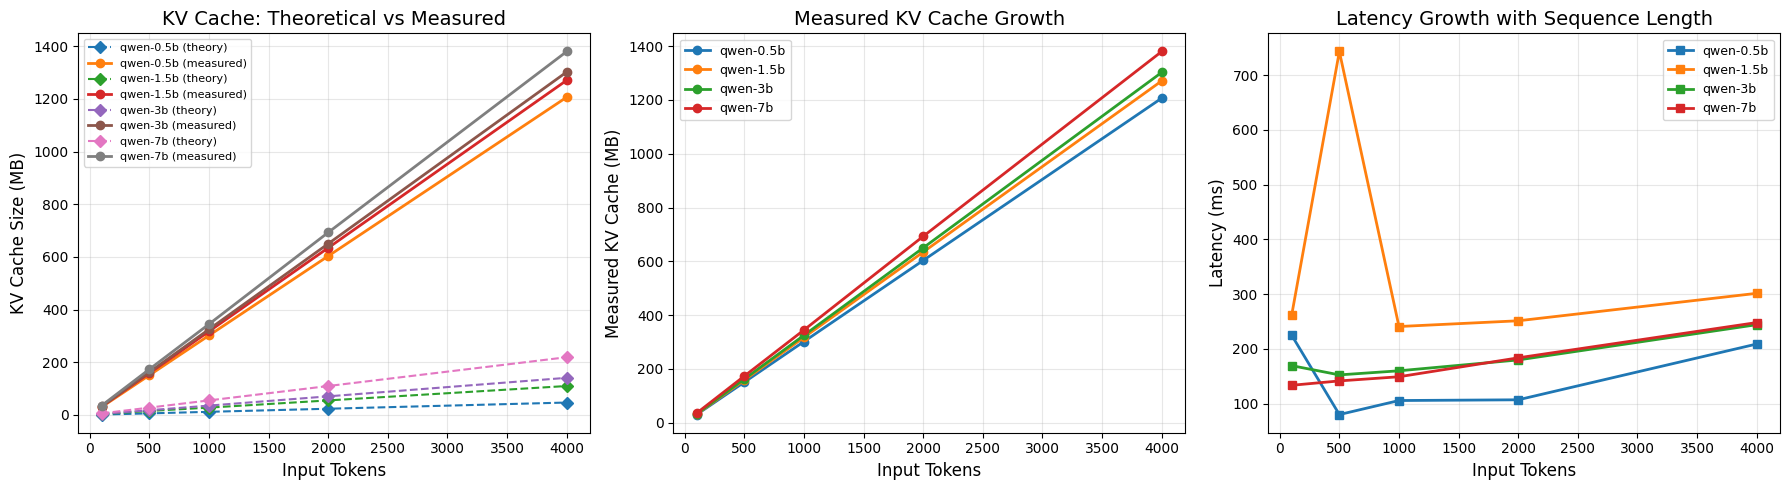

In [20]:
# Measure KV cache growth — all models
sequence_lengths = [100, 500, 1000, 2000, 4000]
all_kv = []
for model_key in MODELS_TO_USE:
    mw = models[model_key]
    mw.load()
    print(f"\nMeasuring KV cache with {model_key} ({mw.config['size']})...")
    df = measure_memory_with_sequence_length(
        mw,
        sequence_lengths,
        output_tokens=50,
        theoretical_kv_cache_mb_fn=theoretical_kv_cache_mb,
    )
    df["model"] = model_key
    all_kv.append(df)
    mw.unload()
test_model.load()

kv_cache_df = pd.concat(all_kv, ignore_index=True)

print("\nResults:")
for model_key in MODELS_TO_USE:
    subset = kv_cache_df[kv_cache_df["model"] == model_key]
    print(f"\n  {model_key}:")
    print(subset[["input_tokens", "measured_kv_mb", "theoretical_kv_mb", "latency_ms"]].to_string(index=False))

plot_kv_cache_growth(kv_cache_df)


---

## Batching – Serve More Users at Once

Up to now, every exercise has handled one request at a time. But GPUs are massively parallel — they can work on several requests simultaneously if you batch them together.

The trade-off: total throughput goes up (more tokens per second across all requests), but each individual request takes a bit longer because it's sharing the GPU.

> **The batching sweet spot:** In practice, inference servers like vLLM and TGI use *continuous batching* — they don't wait for a full batch to form. Instead, they slot new requests into the GPU as old ones finish. This keeps utilization high without forcing any single user to wait for others to arrive. The exercise below uses static batching (simpler), but the throughput-vs-latency tradeoff is the same.

### Exercise 5 – Batched Inference Metrics

The **graded** function does **not** run `generate()`. It takes raw numbers from a batched run (`total_output_tokens`, wall-clock `elapsed_s`, batch size, peak and baseline GPU memory in MB) and returns the dict the plotting helpers expect.

`utils.run_batch_experiment` calls `utils.run_batched_inference_raw(...)` (model code) and then passes the measured values into your function.

**Complete the single line** between `### START CODE HERE ###` and `### END CODE HERE ###`:

```python
    throughput = total_output_tokens / elapsed_s if elapsed_s > 0 else 0
```

> **Note:** This exercise uses peak and baseline memory from the real run; Exercise 3’s `get_gpu_memory_info` is how those values are obtained in `utils`.


In [21]:
# GRADED CELL: exercise 5
def measure_batched_inference(
    total_output_tokens: int,
    elapsed_s: float,
    batch_size: int,
    peak_mem_mb: float,
    mem_before_mb: float,
) -> Dict:
    """
    Turn raw batched-generation measurements into throughput and memory summary fields.
    """
    ### START CODE HERE ###
    throughput = total_output_tokens / elapsed_s if elapsed_s > 0 else 0
    ### END CODE HERE ###
    return {
        "batch_size": batch_size,
        "total_time_s": elapsed_s,
        "time_per_request_ms": elapsed_s * 1000 / batch_size,
        "total_output_tokens": total_output_tokens,
        "throughput_tokens_per_sec": throughput,
        "memory_increase_mb": round(peak_mem_mb - mem_before_mb, 1),
    }


[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



--- qwen-0.5b (0.5B) ---
Testing batching with qwen-0.5b...

Batch 1: 72.7 tok/s, 110ms/req, +3 MB


[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Batch 2: 124.8 tok/s, 401ms/req, +6 MB


[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


...

✓ Loaded Qwen/Qwen2.5-7B-Instruct

--- qwen-7b (7B) ---
Testing batching with qwen-7b...

Batch 1: 63.4 tok/s, 126ms/req, +7 MB


[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Batch 2: 118.6 tok/s, 422ms/req, +14 MB


[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Batch 4: 241.6 tok/s, 207ms/req, +30 MB
Batch 8: 475.7 tok/s, 105ms/req, +58 MB
✓ Unloaded Qwen/Qwen2.5-7B-Instruct
Loading Qwen/Qwen2.5-0.5B-Instruct...
✓ Loaded Qwen/Qwen2.5-0.5B-Instruct


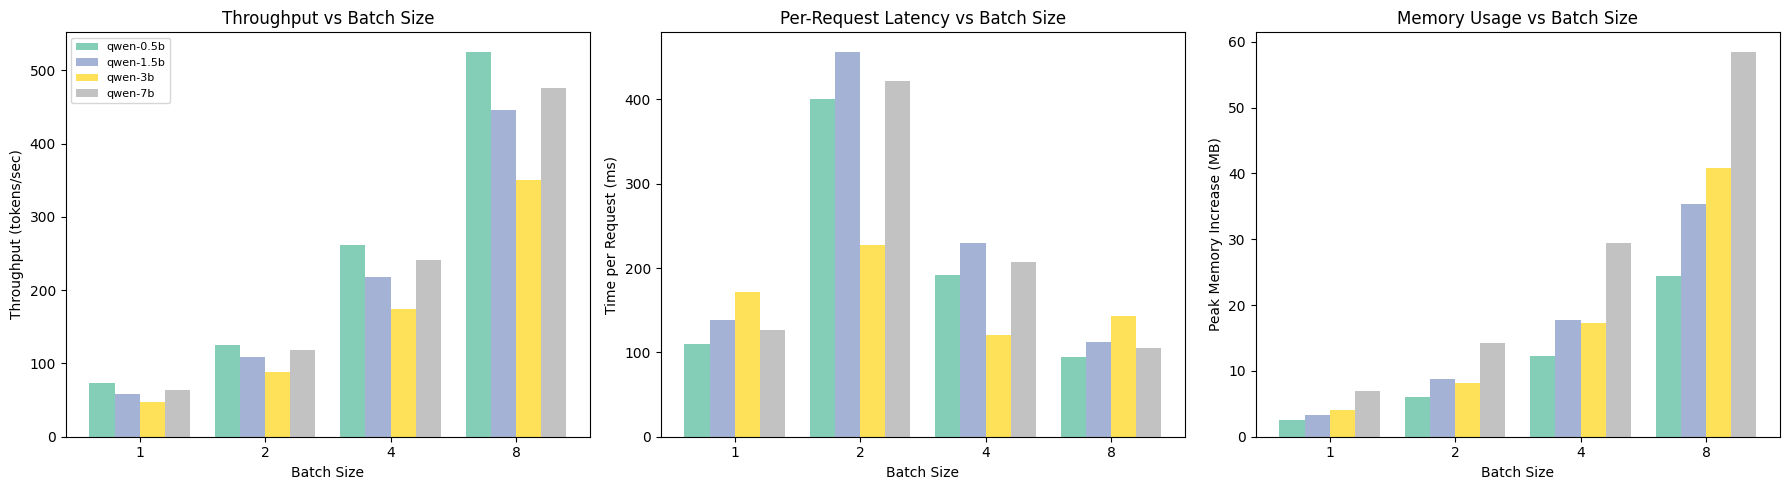

In [22]:
# Batched inference — all models
all_batch = []
for model_key in MODELS_TO_USE:
    mw = models[model_key]
    mw.load()
    print(f"\n--- {model_key} ({mw.config['size']}) ---")
    df = run_batch_experiment(mw, measure_batched_inference)
    df["model"] = model_key
    all_batch.append(df)
    mw.unload()
test_model.load()

batch_df = pd.concat(all_batch, ignore_index=True)
plot_batching_results(batch_df)